In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/navneet0094/jafee-data/README_FIRST.txt
/kaggle/input/datasets/navneet0094/jafee-data/jaffe/NM.SA1.98.tiff
/kaggle/input/datasets/navneet0094/jafee-data/jaffe/YM.SA3.57.tiff
/kaggle/input/datasets/navneet0094/jafee-data/jaffe/KA.DI3.44.tiff
/kaggle/input/datasets/navneet0094/jafee-data/jaffe/KM.AN2.18.tiff
/kaggle/input/datasets/navneet0094/jafee-data/jaffe/MK.HA3.118.tiff
/kaggle/input/datasets/navneet0094/jafee-data/jaffe/NM.FE2.111.tiff
/kaggle/input/datasets/navneet0094/jafee-data/jaffe/TM.HA1.180.tiff
/kaggle/input/datasets/navneet0094/jafee-data/jaffe/UY.FE2.153.tiff
/kaggle/input/datasets/navneet0094/jafee-data/jaffe/UY.DI3.151.tiff
/kaggle/input/datasets/navneet0094/jafee-data/jaffe/YM.NE2.50.tiff
/kaggle/input/datasets/navneet0094/jafee-data/jaffe/TM.SU3.189.tiff
/kaggle/input/datasets/navneet0094/jafee-data/jaffe/MK.NE3.115.tiff
/kaggle/input/datasets/navneet0094/jafee-data/jaffe/MK.SA3.121.tiff
/kaggle/input/datasets/navneet0094/jafee-data/jaffe/NM.HA3

In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

data = []
labels = []

emotion_map = {
    'AN':0, 'DI':1, 'FE':2,
    'HA':3, 'SA':4, 'SU':5, 'NE':6
}


In [3]:

dataset_path = "/kaggle/input/datasets/navneet0094/jafee-data/jaffe"

for img_name in os.listdir(dataset_path):

    img_path = os.path.join(dataset_path, img_name)

    try:
        # grayscale
        img = Image.open(img_path).convert('L') # luminised only if P -> rgb paltetised

        # resize to 128x128
        img = img.resize((128,128))

        img = np.array(img)

        emotion = img_name.split('.')[1][:2]
        label = emotion_map[emotion]

        data.append(img)
        labels.append(label)

    except Exception as e:
        print("Error:", img_name)

data = np.array(data)
labels = np.array(labels)

print("Data shape:", data.shape)
print("Labels:", np.unique(labels))

Data shape: (213, 128, 128)
Labels: [0 1 2 3 4 5 6]


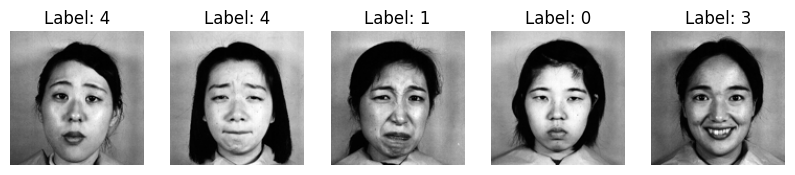

In [4]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(data[i], cmap='gray')
    plt.title(f"Label: {labels[i]}")
    plt.axis('off')

plt.show()

In [5]:
# HOG
from skimage.feature import hog

X_hog = []

for img in data:
    features = hog(
        img,
        orientations=9,
        pixels_per_cell=(8,8),
        cells_per_block=(2,2)
    )
    X_hog.append(features)

X_hog = np.array(X_hog)

print("HOG feature shape:", X_hog.shape)

HOG feature shape: (213, 8100)


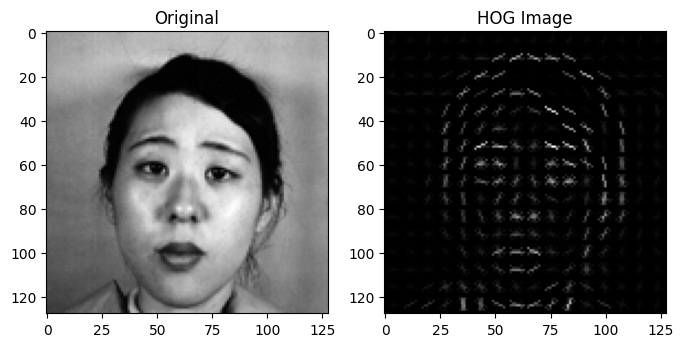

In [6]:
# HOG vis
sample_img = data[0]

features, hog_image = hog(
    sample_img,
    orientations=9,
    pixels_per_cell=(8,8),
    cells_per_block=(2,2),
    visualize=True
)

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(sample_img, cmap='gray')
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(hog_image, cmap='gray')
plt.title("HOG Image")

plt.show()

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, classification_report



In [8]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess


# Load pretrained model (feature extractor)
mobilenet = MobileNetV2(weights='imagenet', include_top=False, pooling='avg')

# VGG
vgg = VGG16(weights='imagenet', include_top=False, pooling='avg')

2026-05-29 10:44:55.270435: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780051495.584477      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780051495.671947      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780051496.466070      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780051496.466127      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780051496.466131      58 computation_placer.cc:177] computation placer alr

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [9]:
import cv2
import numpy as np

def extract_cnn_features(images, model):
    features = []
    
    for img in images:
        img = cv2.resize(img, (224,224))
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
        img = preprocess_input(img)
    
        img = np.expand_dims(img, axis=0)
        
        feat = model.predict(img, verbose=0)
        features.append(feat.flatten())
    
    return np.array(features)

In [10]:
def extract_vgg_features(images, model):
    features = []
    
    for img in images:
        img = cv2.resize(img, (224,224))
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
        img = vgg_preprocess(img)
        
        img = np.expand_dims(img, axis=0)
        feat = model.predict(img, verbose=0)
        
        features.append(feat.flatten())
    
    return np.array(features)

In [11]:
# MobileNet features
X_cnn = extract_cnn_features(data, mobilenet)

print("Mobilenet feature shape:", X_cnn.shape)

Mobilenet feature shape: (213, 1280)


In [12]:
# VGG features
X_vgg = extract_vgg_features(data, vgg)

print("VGG feature shape:", X_vgg.shape)

VGG feature shape: (213, 512)


In [13]:
from sklearn.preprocessing import StandardScaler

# Separate scalers
hog_scaler = StandardScaler()
cnn_scaler = StandardScaler()
vgg_scaler = StandardScaler()

# Normalize features
X_hog_scaled = hog_scaler.fit_transform(X_hog)

X_cnn_scaled = cnn_scaler.fit_transform(X_cnn)

X_vgg_scaled = vgg_scaler.fit_transform(X_vgg)

print("HOG scaled:", X_hog_scaled.shape)
print("CNN scaled:", X_cnn_scaled.shape)
print("VGG scaled:", X_vgg_scaled.shape)

HOG scaled: (213, 8100)
CNN scaled: (213, 1280)
VGG scaled: (213, 512)


## Weighted Fusion

In [14]:
# Features = αH(Hog)​+αM(mobilenet)​+αV(vgg)
# αH​+αM​+αV​=1

# Feature	Attention
# HOG	0.6
# MobileNet	0.3
# VGG	0.1

# Feature	Attention
# HOG	0.7
# MobileNet	0.2
# VGG	0.1

In [15]:
hog_weight =0.6
mobilenet_weight = 0.3
vgg_weight = 0.1

In [16]:
X_hog_weighted = X_hog_scaled * hog_weight

X_mobilenet_weighted = X_cnn_scaled * mobilenet_weight

X_vgg_weighted = X_vgg_scaled * vgg_weight

In [17]:
X_weighted_fusion = np.concatenate([
    X_hog_weighted,
    X_mobilenet_weighted,
    X_vgg_weighted
], axis=1)

print("Weighted Fusion Shape:",
      X_weighted_fusion.shape)

Weighted Fusion Shape: (213, 9892)


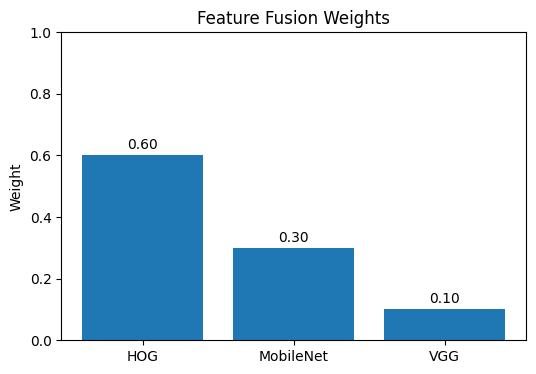

In [18]:
# =========================================
# WEIGHT VISUALIZATION
# =========================================

features = ['HOG', 'MobileNet', 'VGG']

weights = [
    hog_weight,
    mobilenet_weight,
    vgg_weight
]

plt.figure(figsize=(6,4))

bars = plt.bar(features, weights)

plt.ylim(0,1)

plt.title("Feature Fusion Weights")

plt.ylabel("Weight")

# values on top
for bar in bars:

    yval = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval + 0.02,
        f"{yval:.2f}",
        ha='center'
    )

plt.show()

In [19]:
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline

model = Pipeline([

    ('svm', SVC(
        kernel='linear',
        probability=True
    ))
])

In [20]:
from sklearn.model_selection import cross_val_predict

y_probs = cross_val_predict(
    model,
    X_weighted_fusion,
    labels,
    cv=10,
    method='predict_proba'
)

In [21]:
y_probs

array([[0.01498117, 0.0208007 , 0.1355068 , ..., 0.71260947, 0.01737967,
        0.05213166],
       [0.00413277, 0.01680083, 0.06767905, ..., 0.87002948, 0.00428156,
        0.0181985 ],
       [0.07096934, 0.72236247, 0.13363407, ..., 0.03408459, 0.00333783,
        0.00526109],
       ...,
       [0.03154613, 0.07637608, 0.07912414, ..., 0.532441  , 0.04716418,
        0.21309991],
       [0.00594536, 0.04362054, 0.04361486, ..., 0.02755309, 0.02049683,
        0.01654408],
       [0.04317179, 0.04355279, 0.08368038, ..., 0.13548295, 0.06472324,
        0.52013562]], shape=(213, 7))

In [22]:
y_pred = np.argmax(y_probs, axis=1)

confidence_scores = np.max(
    y_probs,
    axis=1
)

In [23]:
from sklearn.metrics import accuracy_score

overall_acc_1 = accuracy_score(labels, y_pred)
print("Weighted Fusion Accuracy:",round(overall_acc_1,4))

Weighted Fusion Accuracy: 0.9061


In [24]:
# CLASSIFICATION REPORT

from sklearn.metrics import classification_report

emotion_names = [
    'anger',
    'disgust',
    'fear',
    'happy',
    'sadness',
    'surprise',
    'neutral'
]

print(

    classification_report(
        labels,
        y_pred,
        target_names=emotion_names
    )

)

              precision    recall  f1-score   support

       anger       1.00      0.90      0.95        30
     disgust       0.81      0.90      0.85        29
        fear       0.84      0.84      0.84        32
       happy       0.91      1.00      0.95        31
     sadness       0.93      0.84      0.88        31
    surprise       0.90      0.93      0.92        30
     neutral       0.97      0.93      0.95        30

    accuracy                           0.91       213
   macro avg       0.91      0.91      0.91       213
weighted avg       0.91      0.91      0.91       213



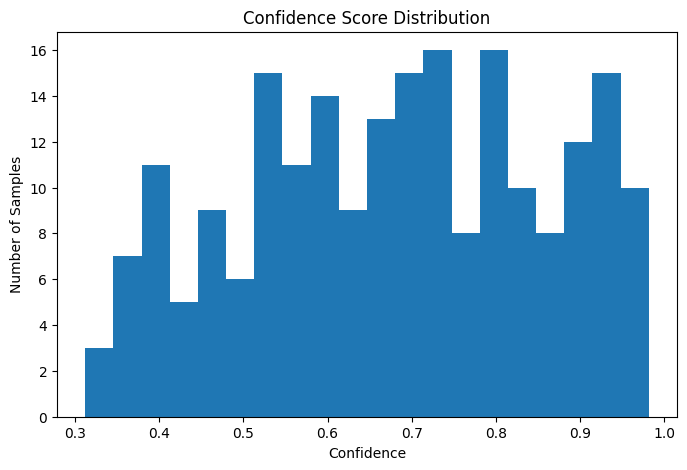

In [25]:
# CONFIDENCE DISTRIBUTION

plt.figure(figsize=(8,5))

plt.hist(
    confidence_scores,
    bins=20
)

plt.title(
    "Confidence Score Distribution"
)

plt.xlabel("Confidence")

plt.ylabel("Number of Samples")

plt.show()

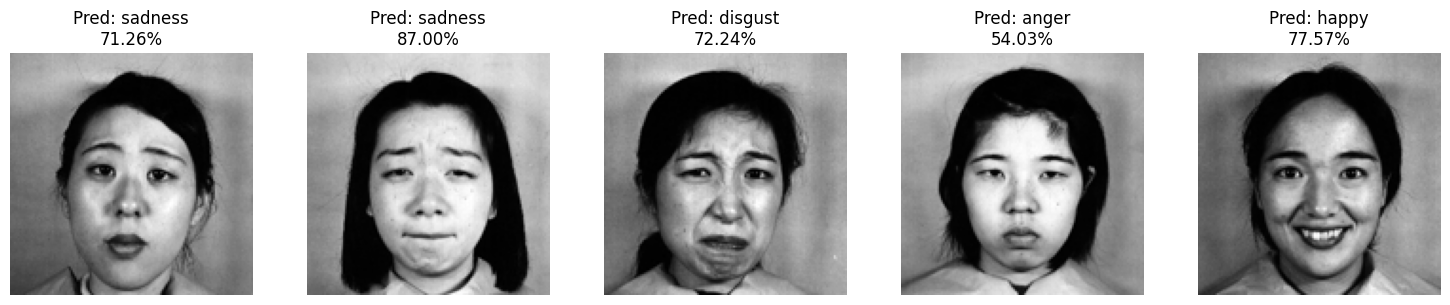

In [26]:
# SAMPLE PREDICTIONS IN SINGLE FIGURE

plt.figure(figsize=(15,3))

for i in range(5):

    plt.subplot(1, 5, i+1)

    plt.imshow(data[i], cmap='gray')

    plt.title(
        f"Pred: {emotion_names[y_pred[i]]}\n"
        f"{confidence_scores[i]*100:.2f}%"
    )

    plt.axis('off')

plt.tight_layout()

plt.show()

In [27]:
# Rejecting Uncertain samples

In [28]:
thresholds = [0.4, 0.5, 0.6, 0.7, 0.8]

In [29]:
thresholds = [0.4, 0.5, 0.6, 0.7, 0.8]

for t in thresholds:

    accepted = confidence_scores >= t

    accepted_accuracy = np.mean(
        y_pred[accepted] == labels[accepted]
    )

    print(f"\nThreshold: {t}")

    print("Accepted:",
          np.sum(accepted))

    print("Rejected:",
          np.sum(~accepted))

    print("Accuracy on accepted samples:",
          accepted_accuracy)


Threshold: 0.4
Accepted: 195
Rejected: 18
Accuracy on accepted samples: 0.9230769230769231

Threshold: 0.5
Accepted: 174
Rejected: 39
Accuracy on accepted samples: 0.9367816091954023

Threshold: 0.6
Accepted: 139
Rejected: 74
Accuracy on accepted samples: 0.9640287769784173

Threshold: 0.7
Accepted: 102
Rejected: 111
Accuracy on accepted samples: 0.9901960784313726

Threshold: 0.8
Accepted: 60
Rejected: 153
Accuracy on accepted samples: 1.0


In [30]:
threshold = 0.6

accepted = confidence_scores >= threshold

rejected = confidence_scores < threshold

print("Accepted Samples:",
      np.sum(accepted))

print("Rejected Samples:",
      np.sum(rejected))

Accepted Samples: 139
Rejected Samples: 74


In [39]:
filtered_acc_1 = accuracy_score(
    labels[accepted],
    y_pred[accepted]
)

print(
    "Accuracy After Rejecting "
    "Uncertain Samples:",
    filtered_acc1
)

NameError: name 'filtered_acc1' is not defined

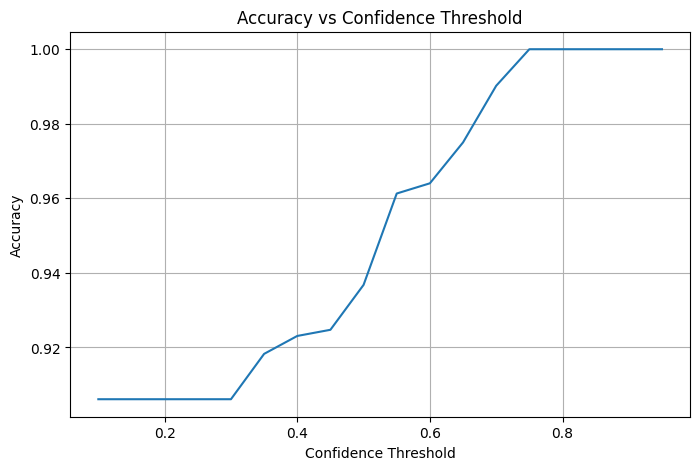

In [33]:
thresholds = np.arange(0.1, 1.0, 0.05)

accuracies = []

for t in thresholds:

    mask = confidence_scores >= t

    if np.sum(mask) > 0:

        acc = accuracy_score(
            labels[mask],
            y_pred[mask]
        )

        accuracies.append(acc)

    else:
        accuracies.append(0)

plt.figure(figsize=(8,5))

plt.plot(thresholds, accuracies)

plt.xlabel("Confidence Threshold")

plt.ylabel("Accuracy")

plt.title(
    "Accuracy vs Confidence Threshold"
)

plt.grid()

plt.show()

In [34]:
# SECOND WEIGHT SET
hog_weight_2 = 0.7
cnn_weight_2 = 0.2
vgg_weight_2 = 0.1

In [35]:
# =========================================
# APPLY NEW WEIGHTS
# =========================================

X_hog_weighted_2 = (
    X_hog_scaled * hog_weight_2
)

X_cnn_weighted_2 = (
    X_cnn_scaled * cnn_weight_2
)

X_vgg_weighted_2 = (
    X_vgg_scaled * vgg_weight_2
)

In [36]:
# =========================================
# SECOND WEIGHTED FUSION
# =========================================

X_weighted_fusion_2 = np.concatenate([

    X_hog_weighted_2,

    X_cnn_weighted_2,

    X_vgg_weighted_2

], axis=1)

print(
    "Fusion Shape:",
    X_weighted_fusion_2.shape
)

Fusion Shape: (213, 9892)


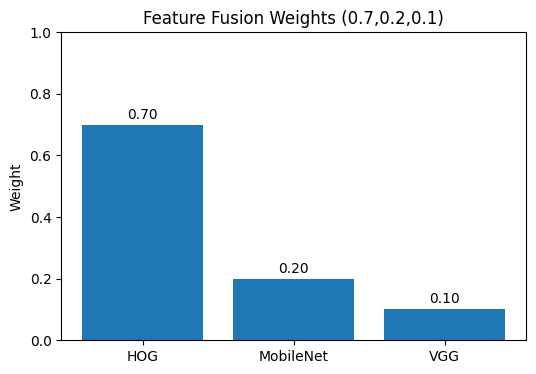

In [37]:
# =========================================
# VISUALIZE WEIGHTS
# =========================================

features = [
    'HOG',
    'MobileNet',
    'VGG'
]

weights_2 = [
    hog_weight_2,
    cnn_weight_2,
    vgg_weight_2
]

plt.figure(figsize=(6,4))

bars = plt.bar(
    features,
    weights_2
)

plt.ylim(0,1)

plt.title(
    "Feature Fusion Weights (0.7,0.2,0.1)"
)

plt.ylabel("Weight")

for bar in bars:

    yval = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval + 0.02,
        f"{yval:.2f}",
        ha='center'
    )

plt.show()

In [38]:
# =========================================
# CONFIDENCE-AWARE SVM
# =========================================

model_2 = Pipeline([

    ('svm', SVC(
        kernel='linear',
        probability=True
    ))
])

In [ ]:
# =========================================
# PREDICT PROBABILITIES
# =========================================

y_probs_2 = cross_val_predict(

    model_2,

    X_weighted_fusion_2,

    labels,

    cv=10,

    method='predict_proba'
)

In [ ]:
# =========================================
# FINAL PREDICTIONS
# =========================================

y_pred_2 = np.argmax(
    y_probs_2,
    axis=1
)

confidence_scores_2 = np.max(
    y_probs_2,
    axis=1
)

In [ ]:
# =========================================
# ACCURACY
# =========================================

overall_acc_2 = accuracy_score(
    labels,
    y_pred_2
)

print(
    "Weighted Fusion Accuracy:",
    round(overall_acc_2,4)
)

In [ ]:
# =========================================
# CONFIDENCE DISTRIBUTION
# =========================================

plt.figure(figsize=(8,5))

plt.hist(
    confidence_scores_2,
    bins=20
)

plt.title(
    "Confidence Distribution (0.7,0.2,0.1)"
)

plt.xlabel("Confidence")

plt.ylabel("Samples")

plt.show()

In [ ]:
# CONFIDENCE THRESHOLD ANALYSIS
thresholds = [0.4, 0.5, 0.6, 0.7, 0.8]

for t in thresholds:

    # Accepted
    accepted_2 = confidence_scores_2 >= t
    rejected_2 = confidence_scores_2 < t

    # Accepted accuracy
    accepted_accuracy_2 = np.mean(
        y_pred_2[accepted_2] == labels[accepted_2]
    )

    print(f"\nThreshold: {t}")

    print("Accepted:",np.sum(accepted_2))

    print("Rejected:",np.sum(rejected_2))

    print("Accepted Accuracy:",accepted_accuracy_2)

  

In [ ]:
# =========================================
# REJECT UNCERTAIN SAMPLES
# =========================================

threshold = 0.6

accepted_2 = (
    confidence_scores_2 >= threshold
)

rejected_2 = (
    confidence_scores_2 < threshold
)

print(
    "Accepted:",
    np.sum(accepted_2)
)

print(
    "Rejected:",
    np.sum(rejected_2)
)

In [ ]:
# FILTERED ACCURACY

filtered_acc_2 = accuracy_score(labels[accepted_2],y_pred_2[accepted_2])

print("Accuracy After Rejection:",round(filtered_acc_2,4))

In [ ]:
# COMPARISON TABLE

import pandas as pd

comparison_df = pd.DataFrame({

    'Fusion Setting': ['0.6 / 0.3 / 0.1','0.7 / 0.2 / 0.1'],

    'Overall Accuracy': [overall_acc_1,overall_acc_2],

    'Filtered Accuracy': [filtered_acc_1,filtered_acc_2],

    'Rejected Samples': [np.sum(rejected),np.sum(rejected_2)]

})

print(comparison_df)

In [ ]:
# from sklearn.metrics import accuracy_score
# from sklearn.model_selection import cross_val_predict

# # -----------------------------
# # Weighted Fusion Predictions
# # -----------------------------
# y_pred = cross_val_predict(
#     model,
#     X_weighted_fusion,
#     labels,
#     cv=10,
#     method='predict'   # get predicted class labels
# )

# # Accuracy
# weighted_fusion_acc = accuracy_score(labels, y_pred)

# print("Weighted Fusion Accuracy:", weighted_fusion_acc)


# # -----------------------------------
# # Learned Weighted Fusion Predictions
# # -----------------------------------
# y_learned_pred = cross_val_predict(
#     model,
#     X_weighted_learned_fusion,
#     labels,
#     cv=10,
#     method='predict'
# )

# # Accuracy
# learned_fusion_acc = accuracy_score(labels, y_learned_pred)

# print("Learned Weighted Fusion Accuracy:", learned_fusion_acc)

In [ ]:
# LEARNED WEIGHTS FROM INDIVIDUAL ACCURACIES

hog_acc = 0.89
mobilenet_acc = 0.86
vgg_acc = 0.74

total = hog_acc + mobilenet_acc + vgg_acc

hog_weight_learned = hog_acc / total
mobilenet_weight_learned = mobilenet_acc / total
vgg_weight_learned = vgg_acc / total

print("HOG Weight:", round(hog_weight_learned,4))
print("MobileNet Weight:", round(mobilenet_weight_learned,4))
print("VGG Weight:", round(vgg_weight_learned,4))

In [ ]:
# APPLY LEARNED WEIGHTS

X_hog_learned_weighted = (X_hog_scaled * hog_weight_learned)

X_mobilenet_learned_weighted = (X_cnn_scaled * mobilenet_weight_learned)

X_vgg_learned_weighted = (X_vgg_scaled * vgg_weight_learned)

In [ ]:
# LEARNED WEIGHTED FUSION

X_learned_weighted_fusion = np.concatenate([X_hog_learned_weighted,X_mobilenet_learned_weighted,X_vgg_learned_weighted], axis=1)

print("Fusion Shape:",X_learned_weighted_fusion.shape)

In [ ]:
# =========================================
# VISUALIZE LEARNED WEIGHTS
# =========================================

features = ['HOG', 'MobileNet', 'VGG']

weights = [
    hog_weight_learned,
    mobilenet_weight_learned,
    vgg_weight_learned
]

plt.figure(figsize=(6,4))

bars = plt.bar(features, weights)

plt.ylim(0,1)

plt.title("Learned Feature Fusion Weights")

plt.ylabel("Weight")

for bar in bars:

    yval = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval + 0.02,
        f"{yval:.2f}",
        ha='center'
    )

plt.show()

In [ ]:
# CONFIDENCE-AWARE SVM

from sklearn.svm import SVC
from sklearn.pipeline import Pipeline

model_learned = Pipeline([

    ('svm', SVC(
        kernel='linear',
        probability=True
    ))
])

In [ ]:
# PREDICT PROBABILITIES

from sklearn.model_selection import cross_val_predict

y_probs_learned = cross_val_predict(

    model_learned,

    X_learned_weighted_fusion,

    labels,

    cv=10,

    method='predict_proba'
)

In [ ]:
# FINAL PREDICTIONS

y_pred_learned = np.argmax(
    y_probs_learned,
    axis=1
)

confidence_scores_learned = np.max(
    y_probs_learned,
    axis=1
)

In [ ]:
# OVERALL ACCURACY

from sklearn.metrics import accuracy_score

overall_acc_learned = accuracy_score(
    labels,
    y_pred_learned
)

print(
    "Learned Weighted Fusion Accuracy:",
    round(overall_acc_learned,4)
)

In [ ]:
# CLASSIFICATION REPORT
from sklearn.metrics import classification_report

print(

    classification_report(
        labels,
        y_pred_learned,
        target_names=emotion_names
    )

)

In [ ]:
# =========================================
# CONFIDENCE THRESHOLD ANALYSIS
# =========================================

thresholds = [0.4, 0.5, 0.6, 0.7, 0.8]

for t in thresholds:

    accepted_learned = (
        confidence_scores_learned >= t
    )

    rejected_learned = (
        confidence_scores_learned < t
    )

    accepted_accuracy_learned = np.mean(

        y_pred_learned[accepted_learned]

        ==

        labels[accepted_learned]
    )

    print(f"\nThreshold: {t}")

    print(
        "Accepted:",
        np.sum(accepted_learned)
    )

    print(
        "Rejected:",
        np.sum(rejected_learned)
    )

    print(
        "Accepted Accuracy:",
        accepted_accuracy_learned
    )

In [ ]:
# FILTERED ACCURACY

threshold = 0.6

accepted_learned = (confidence_scores_learned >= threshold)

filtered_acc_learned = accuracy_score(labels[accepted_learned],y_pred_learned[accepted_learned])

print("Filtered Accuracy:",round(filtered_acc_learned,4))

In [ ]:
# FINAL COMPARISON TABLE

comparison_df = pd.DataFrame({

    'Fusion Method': ['Manual (0.6,0.3,0.1)','Manual (0.7,0.2,0.1)','Learned Weights'],

    'Overall Accuracy': [
        overall_acc_1,
        overall_acc_2,
        overall_acc_learned
    ],
    'Filtered Accuracy': [
        filtered_acc_1,
        filtered_acc_2,
        filtered_acc_learned
    ]
})
print(comparison_df)

In [ ]:
# # FINAL FUSION COMPARISON

# methods = [
#     'Manual\n(0.6,0.3,0.1)',
#     'Manual\n(0.7,0.2,0.1)',
#     'Learned\nWeights'
# ]
# overall_accs = [
#     overall_acc_1,
#     overall_acc_2,
#     overall_acc_learned
# ]
# filtered_accs = [
#     filtered_acc_1,
#     filtered_acc_2,
#     filtered_acc_learned
# ]
# x = np.arange(len(methods))
# width = 0.35
# plt.figure(figsize=(8,5))
# plt.bar(
#     x - width/2,
#     overall_accs,
#     width,
#     label='Overall Accuracy'
# )

# plt.bar(
#     x + width/2,
#     filtered_accs,
#     width,
#     label='Filtered Accuracy'
# )

# plt.xticks(x, methods)

# plt.ylim(0.8,1.0)

# plt.ylabel("Accuracy")

# plt.title(
#     "Fusion Method Comparison"
# )

# plt.legend()

# plt.show()

In [ ]:
print(f"Weighted Fusion Accuracy: {overall_acc_1*100:.2f}%")

print(f"Second Weighted Fusion Accuracy: {overall_acc_2*100:.2f}%")

print(f"Learned Weighted Fusion Accuracy: {overall_acc_learned*100:.2f}%")

In [ ]:
print(f"Filtered Accuracy (0.6,0.3,0.1): {filtered_acc_1*100:.2f}%")

print(f"Filtered Accuracy (0.7,0.2,0.1): {filtered_acc_2*100:.2f}%")

print(f"Filtered Accuracy (Learned Weights): {filtered_acc_learned*100:.2f}%")